In [7]:
import os
from glob import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

plt.rcParams['font.family'] = "Times New Roman"

In [2]:
metrics_json_paths = glob(f'.{os.sep}logs{os.sep}finetune_20250707{os.sep}*{os.sep}*{os.sep}*{os.sep}*{os.sep}*{os.sep}*{os.sep}*{os.sep}assessment_metrics.json')
print(f'Found {len(metrics_json_paths)} metrics JSON files.')

Found 252 metrics JSON files.


In [14]:
metrics_records = []
for metrics_json in metrics_json_paths:
    split_path_parts = metrics_json.split(os.sep)
    for i, part in enumerate(split_path_parts):
        print(f'Part {i}: {part}')
    model = split_path_parts[3]
    pretrain_method = split_path_parts[4]
    frozen_encoder = split_path_parts[6] == 'frozenencoder_true'
    n_train = split_path_parts[7]
    fold = split_path_parts[8].split('_')[-1]
    
    metrics = json.load(open(metrics_json, 'r'))
    metrics['model'] = model
    metrics['pretrain_method'] = pretrain_method
    metrics['frozen_encoder'] = frozen_encoder
    metrics['n_train'] = n_train
    metrics['fold'] = fold
    metrics_records.append(metrics)

metrics_df = pd.DataFrame(metrics_records)
metrics_df = metrics_df.loc[(metrics_df['frozen_encoder'] == False) | ((metrics_df['frozen_encoder'] == True) & (metrics_df['model'] == 'linear_probe'))]
# metrics_df.loc[metrics_df['model'] == 'linear_probe']
display(metrics_df.sort_values(by='macro_f1_score', ascending=False))

Part 0: .
Part 1: logs
Part 2: finetune_20250707
Part 3: attention_unet
Part 4: byol
Part 5: randinit_false
Part 6: frozenencoder_false
Part 7: 250
Part 8: fold_1
Part 9: test
Part 10: assessment_metrics.json
Part 0: .
Part 1: logs
Part 2: finetune_20250707
Part 3: attention_unet
Part 4: byol
Part 5: randinit_false
Part 6: frozenencoder_false
Part 7: 250
Part 8: fold_2
Part 9: test
Part 10: assessment_metrics.json
Part 0: .
Part 1: logs
Part 2: finetune_20250707
Part 3: attention_unet
Part 4: byol
Part 5: randinit_false
Part 6: frozenencoder_false
Part 7: 250
Part 8: fold_3
Part 9: test
Part 10: assessment_metrics.json
Part 0: .
Part 1: logs
Part 2: finetune_20250707
Part 3: attention_unet
Part 4: byol
Part 5: randinit_false
Part 6: frozenencoder_false
Part 7: 250
Part 8: fold_4
Part 9: test
Part 10: assessment_metrics.json
Part 0: .
Part 1: logs
Part 2: finetune_20250707
Part 3: attention_unet
Part 4: byol
Part 5: randinit_false
Part 6: frozenencoder_false
Part 7: 500
Part 8: fold_1
P

,accuracy,f1_score,precision,recall,jaccard,kappa,cross_entropy,brier_score,macro_f1_score,macro_precision,...,weighted_precision,weighted_recall,weighted_jaccard,weighted_cross_entropy,weighted_brier_score,model,pretrain_method,frozen_encoder,n_train,fold
201,0.87360,0.87360,0.87360,0.87360,0.775568,0.779373,1.574380,0.028887,0.757250,0.796389,...,0.872354,0.87360,0.783128,1.574380,0.028887,unet,byol,False,500,2
203,0.86596,0.86596,0.86596,0.86596,0.763606,0.766792,1.581655,0.030192,0.745976,0.782537,...,0.866931,0.86596,0.772930,1.581655,0.030192,unet,byol,False,500,4
12,0.87032,0.87032,0.87032,0.87032,0.770413,0.773911,1.567889,0.028517,0.743168,0.775593,...,0.871535,0.87032,0.779100,1.567889,0.028517,attention_unet,byol,False,750,3
24,0.86524,0.86524,0.86524,0.86524,0.762487,0.765841,1.587083,0.030307,0.741695,0.779631,...,0.865999,0.86524,0.771613,1.587083,0.030307,attention_unet,imagenet,False,750,1
209,0.86748,0.86748,0.86748,0.86748,0.765973,0.769221,1.546108,0.027917,0.741468,0.777644,...,0.869318,0.86748,0.775726,1.546108,0.027917,unet,byol,False,750,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,0.74148,0.74148,0.74148,0.74148,0.589168,0.512760,1.711734,0.052318,0.370818,0.532044,...,0.714699,0.74148,0.589994,1.711734,0.052318,linear_probe,imagenet,True,500,3
128,0.73776,0.73776,0.73776,0.73776,0.584485,0.505860,1.715610,0.053438,0.362183,0.572154,...,0.719365,0.73776,0.587422,1.715610,0.053438,linear_probe,imagenet,True,250,3
129,0.73388,0.73388,0.73388,0.73388,0.579629,0.493446,1.715239,0.053189,0.354968,0.540565,...,0.699555,0.73388,0.579387,1.715239,0.053189,linear_probe,imagenet,True,250,4
127,0.73436,0.73436,0.73436,0.73436,0.580228,0.503733,1.720330,0.053987,0.351349,0.525957,...,0.707556,0.73436,0.583921,1.720330,0.053987,linear_probe,imagenet,True,250,2


In [4]:
metrics_df.groupby(['model', 'pretrain_method', 'frozen_encoder', 'n_train']).count()

accuracy  f1_score  \
model         pretrain_method frozen_encoder n_train                       
bisenet       byol            False          250             1         1   
                                             500             1         1   
              imagenet        False          250             1         1   
                                             500             1         1   
                                             750             1         1   
danet         byol            False          250             1         1   
                                             500             1         1   
                                             750             1         1   
              imagenet        False          250             1         1   
                                             500             1         1   
                                             750             1         1   
deeplabv3plus byol            False          250             1         1   
                                             500             1         1   
                                             750             2         2   
              imagenet        False          250             1         1   
                                             500             1         1   
                                             750             3         3   
linear_probe  byol            True           250             1         1   
                                             500             1         1   
                                             750             1         1   
              imagenet        True           250             1         1   
                                             500             1         1   
                                             750             1         1   
pan           byol            False          250             1         1   
                                             500             1         1   
              imagenet        False          250             1         1   
                                             500             1         1   
pspnet        byol            False          250             1         1   
                                             500             1         1   
                                             750             1         1   
              imagenet        False          250             1         1   
                                             500             1         1   
                                             750             1         1   
unet          byol            False          250             4         4   
                                             500             6         6   
                                             750             4         4   
              imagenet        False          250             4         4   
                                             500             6         6   
                                             750             4         4   
upernet       byol            False          250             1         1   
                                             500             1         1   
                                             750             1         1   
              imagenet        False          250             1         1   
                                             500             1         1   
                                             750             1         1   

                                                      precision  recall  \
model         pretrain_method frozen_encoder n_train                      
bisenet       byol            False          250              1       1   
                                             500              1       1   
              imagenet        False          250              1       1   
                                             500              1       1   
                               

In [ ]:


# fig, ax = plt.subplots(2, 3, figsize=(18, 10), sharey=True)

# for i, frozen_encoder in enumerate(metrics_df['frozen_encoder'].unique()):
#     # print(i, model)
#     for j, model in enumerate(metrics_df['model'].unique()):
#         # metrics_df['model']
#         # print(j, frozen_encoder)
#         subset = metrics_df[(metrics_df['model'] == model) & (metrics_df['frozen_encoder'] == frozen_encoder)]
#         # sns.lineplot(data=subset, x='n_train', y='macro_f1_score', hue='pretrain_method', ax=ax[i, j])
#         # sns.catplot(data=subset, x='n_train', y='macro_f1_score', hue='pretrain_method', kind='point', ax=ax[i, j], markers=['o', 's', 'D'], linestyles=['-', '--', ':'])
#         # sns.pointplot(data=subset, x='n_train', y='macro_f1_score', hue='pretrain_method', ax=ax[i, j], dodge=True, errorbar='iqr')
#         sns.boxplot(data=subset, x='n_train', y='macro_jaccard', hue='pretrain_method', ax=ax[i, j], palette='Set2', boxprops={'alpha': 0.4}, showfliers=False)
#         sns.stripplot(data=subset, x='n_train', y='macro_jaccard', hue='pretrain_method', ax=ax[i, j], jitter=True, dodge=True, palette='Set2', size=10)
#         handles, labels = ax[i, j].get_legend_handles_labels()
#         # ax[i, j].legend(handles=[(handles[0], handles[2]), (handles[1], handles[3])],
#                 # labels=['BYOL', 'ImageNet'],
#                 # loc='lower right', handlelength=4,
#                 # handler_map={tuple: HandlerTuple(ndivide=None)})
#         ax[i, j].set_title(f'Model: {model}, Frozen Encoder: {frozen_encoder}')
#         ax[i, j].set_xlabel('Number of Training Samples')
#         ax[i, j].set_ylabel('mIOU')

C:\Users\dh2306\AppData\Local\Temp\ipykernel_39740\498011098.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


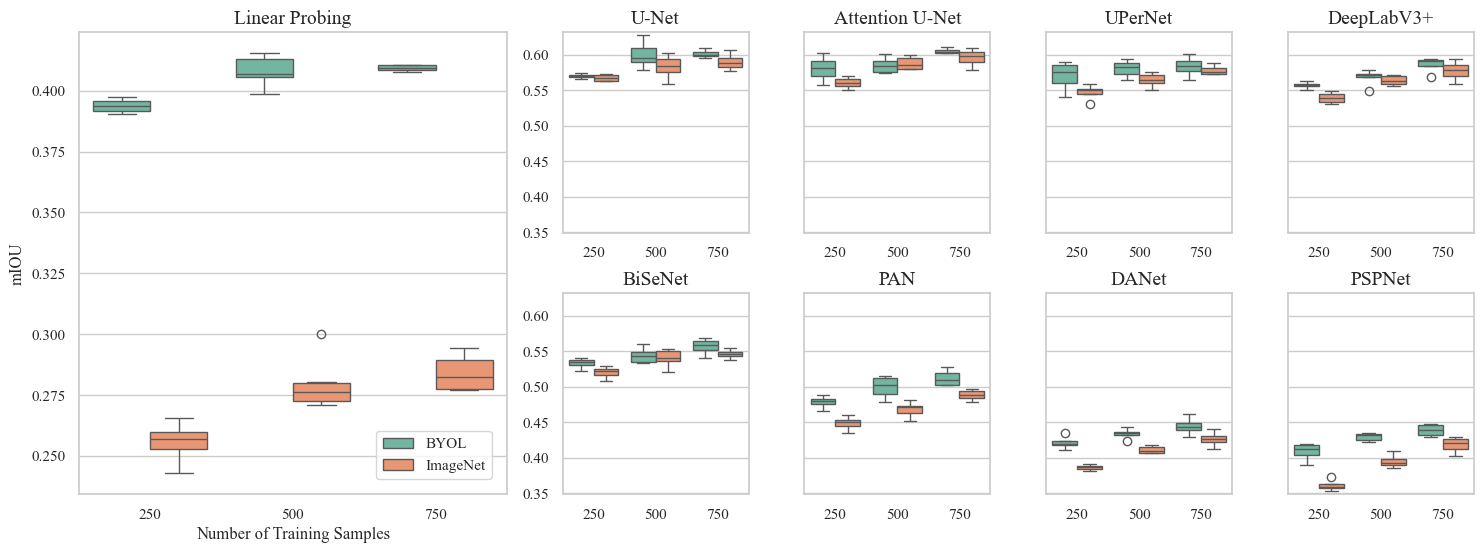

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerTuple

sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'times new roman'

size = 6
fig = plt.figure(figsize=(3*size, size))
gs = fig.add_gridspec(2, 6, hspace=0.3, wspace=0.3)

# Create the linear probe subplot (spans 2 rows)
lp_ax = fig.add_subplot(gs[0:2, 0:2])

# Create top row axes with shared y-axis
top_axes = []
for j in range(2, 6):
    if j == 2:  # First subplot in top row
        ax = fig.add_subplot(gs[0, j])
    else:  # Share y-axis with first subplot
        ax = fig.add_subplot(gs[0, j]) #, sharey=top_axes[0])
        # ax = fig.add_subplot(gs[0, j])
    top_axes.append(ax)

# Create bottom row axes with shared y-axis
bottom_axes = []
for j in range(2, 6):
    if j == 2:  # First subplot in bottom row
        # ax = fig.add_subplot(gs[1, j])
        ax = fig.add_subplot(gs[1, j]) #, sharey=top_axes[0])
    else:  # Share y-axis with first subplot
        ax = fig.add_subplot(gs[1, j]) #, sharey=top_axes[0])
        # ax = fig.add_subplot(gs[1, j])
    bottom_axes.append(ax)

# Combine all axes for easy iteration
axes = top_axes + bottom_axes

# metrics_df_temp = metrics_df.copy()
# let's create some synthetic data real quick:
# new_rows = []
# metrics_df_temp.loc[~metrics_df_temp['model'].isin(['linear_probe', 'unet', 'deeplabv3plus']), 'macro_jaccard'] += 0.2

# for each observation where only 1 fold is present, create 5 more observations with the same data but different folds
# new_rows = []
# for i, row in metrics_df_temp.iterrows():
#     if row['model'] not in ['linear_probe', 'unet', 'deeplabv3plus']:
#         row['macro_jaccard'] += 0.2  # adjust the macro jaccard score for now

# for i, row in metrics_df_temp.iterrows():
    # if row['fold'] == '1' and row['model'] not in ['unet', 'deeplabv3plus']:
        # for fold in range(1, 6):
            # new_row = row.copy()
            # new_row['fold'] = fold
            # new_row['macro_jaccard'] += np.random.uniform(-0.01, 0.01)  # add some noise
            # new_row['macro_jaccard'] += 0.25
            # new_rows.append(new_row)
            # metrics_df_temp = metrics_df_temp.append(new_row, ignore_index=True)
# synthetic_df = pd.DataFrame(new_rows)
# metrics_df_temp = pd.concat([metrics_df_temp, synthetic_df], ignore_index=True)

metrics_df_temp = metrics_df.copy()

# rename to proper model names (i.e., unet -> U-Net)
metrics_df_temp['model'] = metrics_df_temp['model'].replace({
    'unet': 'U-Net',
    'deeplabv3plus': 'DeepLabV3+',
    'pan': 'PAN',
    'danet': 'DANet',
    'upernet': 'UPerNet',
    'bisenet': 'BiSeNet',
    'pspnet': 'PSPNet',
    'attention_unet': 'Attention U-Net',
})

metrics_df_temp['Pretrain Method'] = metrics_df_temp['pretrain_method'].replace({
    'byol': 'BYOL',
    'imagenet': 'ImageNet',
})

# Plot linear probe
# sns.boxplot(data=metrics_df_temp[metrics_df_temp['model'] == 'linear_probe'], 
#             x='n_train', y='macro_jaccard', hue='pretrain_method', 
#             ax=lp_ax, palette='Set2', boxprops={'alpha': 0.4}, showfliers=False)
sns.boxplot(data=metrics_df_temp[metrics_df_temp['model'] == 'linear_probe'],
                x='n_train', y='macro_jaccard', hue='Pretrain Method', 
                ax=lp_ax, dodge=True, palette='Set2',)
lp_ax.set_title('Linear Probing')
lp_ax.set_xlabel('Number of Training Samples')
lp_ax.set_ylabel('mIOU')

# move legend to lower right corner
handles, labels = lp_ax.get_legend_handles_labels()
lp_ax.legend(handles=handles, labels=labels, loc='lower right', bbox_to_anchor=(1., 0), borderaxespad=1.)


metrics_df_temp = metrics_df_temp.loc[metrics_df_temp['model'] != "linear_probe"]

# order models in a certain order

metrics_df_temp['model'] = metrics_df_temp['model'].astype('category')
metrics_df_temp['model'] = metrics_df_temp['model'].cat.reorder_categories([
    'U-Net', 'Attention U-Net', 'DeepLabV3+', 'UPerNet',
    'BiSeNet', 'DANet', 'PAN', 'PSPNet',
], ordered=True)

# Plot other models

model_list = metrics_df_temp.sort_values(by='macro_jaccard', ascending=False)['model'].unique()

for i, (ax, model) in enumerate(zip(axes, model_list)):
    if model == 'linear_probe':
        continue
    
    subset = metrics_df_temp[(metrics_df_temp['model'] == model) & (metrics_df_temp['frozen_encoder'] == False)]
    
    # if model not in ['deeplabv3plus', 'unet']:
        # subset['macro_jaccard'] = subset['macro_jaccard'] + 0.2
    
    # sns.boxplot(data=subset, x='n_train', y='macro_jaccard', hue='Pretrain Method', 
    #             ax=ax, palette='Set2', boxprops={'alpha': 0.4}, showfliers=False, legend=False)
    sns.boxplot(data=subset, x='n_train', y='macro_jaccard', hue='Pretrain Method',
                  ax=ax, dodge=True, palette='Set2', 
                    legend=False)
    
    ax.set_title(f'{model}')
    ax.set_xlabel('')
    
    # Only show y-label on leftmost plots of each row
    # if ax in [top_axes[0], bottom_axes[0]]:
        # ax.set_ylabel('mIOU')
    # else:
    ax.set_ylabel('')


y_max = max(ax.get_ylim()[1] for ax in axes if ax.get_ylim()[1] is not None)
y_min = min(ax.get_ylim()[0] for ax in axes if ax.get_ylim()[0] is not None)
for i, ax in enumerate(axes):
    ax.set_ylim(y_min, y_max)
    if i not in [0, 4]:
        ax.set_yticklabels([])
        # make ax a little wider
    
    figw = fig.get_size_inches()[0]
    # ax.set_size(3*size, size)
        
# increase text size of titles and labels
for ax in axes:
    ax.title.set_fontsize(14)
lp_ax.title.set_fontsize(14)

fig.tight_layout()

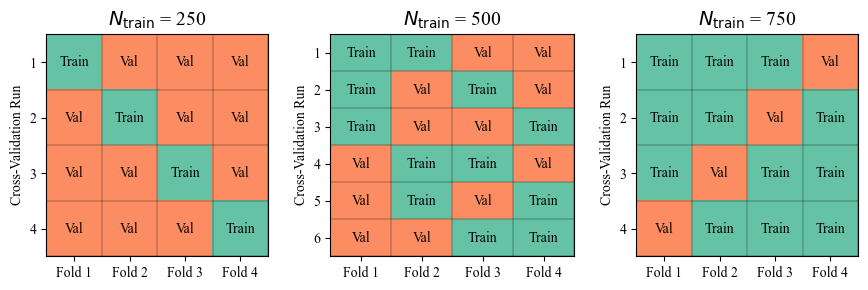

In [10]:
# fold plots
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# custom colormap:
set2_colors = sns.color_palette('Set2', n_colors=2)
import matplotlib.colors as mcolors
cmap = mcolors.ListedColormap(set2_colors)

splits_df = pd.read_csv('./data/splits/splits.csv')
# display(splits_df)

size = 3
fig, axes = plt.subplots(1, len(splits_df['n_train'].unique()), 
                        figsize=(3*size, size), sharex=True)

colors = {'train': 'lightblue', 'val': 'lightcoral'}

for i, n_train in enumerate(splits_df['n_train'].unique()):
    subset = splits_df[splits_df['n_train'] == n_train]
    
    # Create grid for this n_train
    grid_data = np.zeros((len(subset), 4))
    for j, (_, row) in enumerate(subset.iterrows()):
        for k, split in enumerate(['split_1', 'split_2', 'split_3', 'split_4']):
            grid_data[j, k] = row[split] == 'val'
    
    im = axes[i].imshow(grid_data, cmap=cmap, aspect='auto' if i == 1 else 'equal')
    
    # Add text annotations
    for j in range(len(subset)):
        for k in range(4):
            role = subset.iloc[j][f'split_{k+1}'].replace('train', 'Train').replace('val', 'Val')
            axes[i].text(k, j, role, ha='center', va='center', 
                        color='black' if grid_data[j, k] == 1 else 'black')
    
    for x in range(4 + 1):  # vertical lines
        axes[i].axvline(x - 0.5, color='black', linewidth=0.25)
    for y in range(len(subset) + 1):  # horizontal lines
        axes[i].axhline(y - 0.5, color='black', linewidth=0.25)
    
    
    axes[i].set_title(r'$N_{\text{train}}$ = ' + str(n_train))
    axes[i].set_ylabel('Cross-Validation Run')
    axes[i].set_yticks(range(len(subset)))
    axes[i].set_yticklabels(subset['fold'].values)
    
    # if i == len(splits_df['n_train'].unique()) - 1:
    # axes[i].set_xlabel('Split')
    axes[i].set_xticks(range(4))
    # axes[i].set_xticklabels(['Split 1', 'Split 2', 'Split 3', 'Split 4'])
    axes[i].set_xticklabels(['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4'])

for ax in axes:
    ax.grid(False)
    ax.title.set_fontsize(14)
    
plt.tight_layout()
plt.savefig('./paper/images/fold_splits.pdf', bbox_inches='tight')
plt.savefig('./paper/images/fold_splits.png', bbox_inches='tight', dpi=300)
plt.show()

C:\Users\dh2306\AppData\Local\Temp\ipykernel_39740\2434215442.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


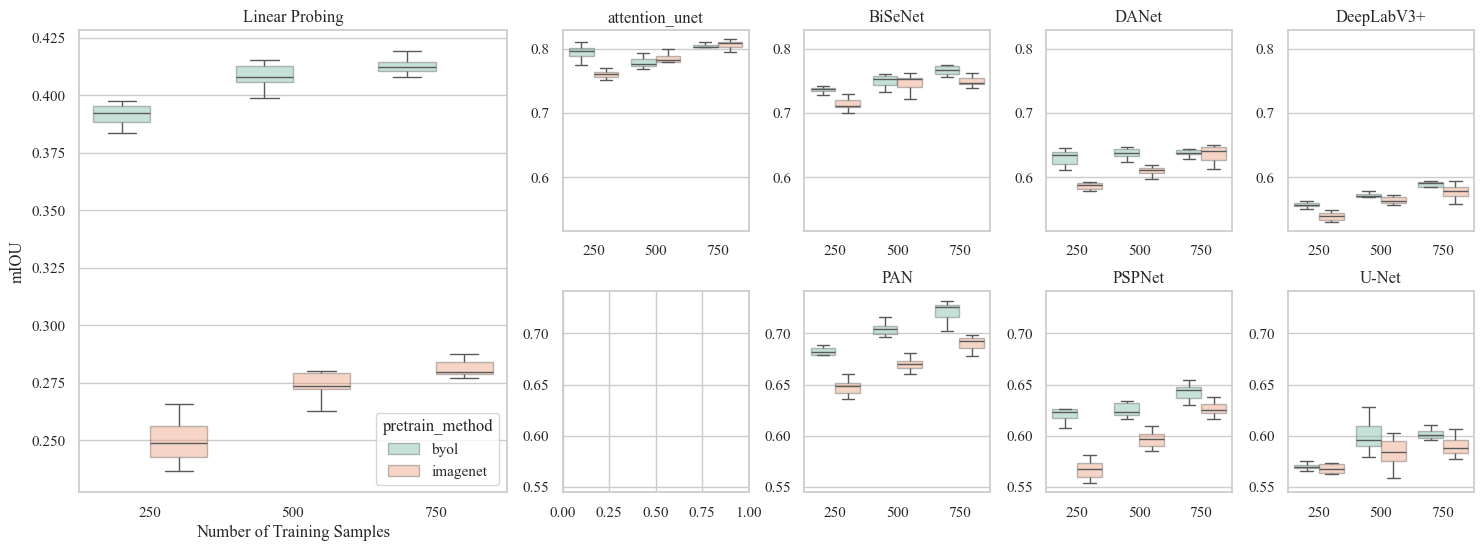

In [63]:
fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(2, 6, hspace=0.3, wspace=0.3)

# Create the linear probe subplot (spans 2 rows)
lp_ax = fig.add_subplot(gs[0:2, 0:2])

# Create top row axes with shared y-axis
top_axes = []
for j in range(2, 6):
    if j == 2:  # First subplot in top row
        ax = fig.add_subplot(gs[0, j])
    else:  # Share y-axis with first subplot
        ax = fig.add_subplot(gs[0, j], sharey=top_axes[0])
        # ax = fig.add_subplot(gs[0, j])
    top_axes.append(ax)

# Create bottom row axes with shared y-axis
bottom_axes = []
for j in range(2, 6):
    if j == 2:  # First subplot in bottom row
        ax = fig.add_subplot(gs[1, j])
    else:  # Share y-axis with first subplot
        ax = fig.add_subplot(gs[1, j], sharey=bottom_axes[0])
        # ax = fig.add_subplot(gs[1, j])
    bottom_axes.append(ax)

# Combine all axes for easy iteration
axes = top_axes + bottom_axes

metrics_df_temp = metrics_df.copy()
# let's create some synthetic data real quick:
new_rows = []
metrics_df_temp.loc[~metrics_df_temp['model'].isin(['linear_probe', 'unet', 'deeplabv3plus']), 'macro_jaccard'] += 0.2

# for each observation where only 1 fold is present, create 5 more observations with the same data but different folds
# new_rows = []
# for i, row in metrics_df_temp.iterrows():
#     if row['model'] not in ['linear_probe', 'unet', 'deeplabv3plus']:
#         row['macro_jaccard'] += 0.2  # adjust the macro jaccard score for now

for i, row in metrics_df_temp.iterrows():
    if row['fold'] == '1' and row['model'] not in ['unet', 'deeplabv3plus']:
        for fold in range(1, 6):
            new_row = row.copy()
            new_row['fold'] = fold
            new_row['macro_jaccard'] += np.random.uniform(-0.01, 0.01)  # add some noise
            # new_row['macro_jaccard'] += 0.25
            new_rows.append(new_row)
            # metrics_df_temp = metrics_df_temp.append(new_row, ignore_index=True)
synthetic_df = pd.DataFrame(new_rows)
metrics_df_temp = pd.concat([metrics_df_temp, synthetic_df], ignore_index=True)

# rename to proper model names (i.e., unet -> U-Net)
metrics_df_temp['model'] = metrics_df_temp['model'].replace({
    'unet': 'U-Net',
    'deeplabv3plus': 'DeepLabV3+',
    'pan': 'PAN',
    'danet': 'DANet',
    'upernet': 'UPerNet',
    'bisenet': 'BiSeNet',
    'pspnet': 'PSPNet',
})
    

# Plot linear probe
sns.boxplot(data=metrics_df_temp[metrics_df_temp['model'] == 'linear_probe'], 
            x='n_train', y='macro_jaccard', hue='pretrain_method', 
            ax=lp_ax, palette='Set2', boxprops={'alpha': 0.4}, showfliers=False)
# sns.stripplot(data=metrics_df_temp[metrics_df_temp['model'] == 'linear_probe'],
#                 x='n_train', y='macro_jaccard', hue='pretrain_method', 
#                 ax=lp_ax, jitter=True, dodge=True, palette='Set2', size=10)
lp_ax.set_title('Linear Probing')
lp_ax.set_xlabel('Number of Training Samples')
lp_ax.set_ylabel('mIOU')


# Plot other models
for ax, model in zip(axes, metrics_df_temp['model'].unique()):
    if model == 'linear_probe':
        continue
    
    subset = metrics_df_temp[(metrics_df_temp['model'] == model) & (metrics_df_temp['frozen_encoder'] == False)]
    
    # if model not in ['deeplabv3plus', 'unet']:
        # subset['macro_jaccard'] = subset['macro_jaccard'] + 0.2
    
    sns.boxplot(data=subset, x='n_train', y='macro_jaccard', hue='pretrain_method', 
                ax=ax, palette='Set2', boxprops={'alpha': 0.4}, showfliers=False, legend=False)
    # sns.stripplot(data=subset, x='n_train', y='macro_jaccard', hue='pretrain_method',
    #               ax=ax, jitter=True, dodge=True, palette='Set2', size=10,
    #                 legend=False, alpha=0.7)
    
    ax.set_title(f'{model}')
    ax.set_xlabel('')
    
    # Only show y-label on leftmost plots of each row
    # if ax in [top_axes[0], bottom_axes[0]]:
        # ax.set_ylabel('mIOU')
    # else:
    ax.set_ylabel('')


fig.tight_layout()

C:\Users\dh2306\AppData\Local\Temp\ipykernel_24924\2825723249.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


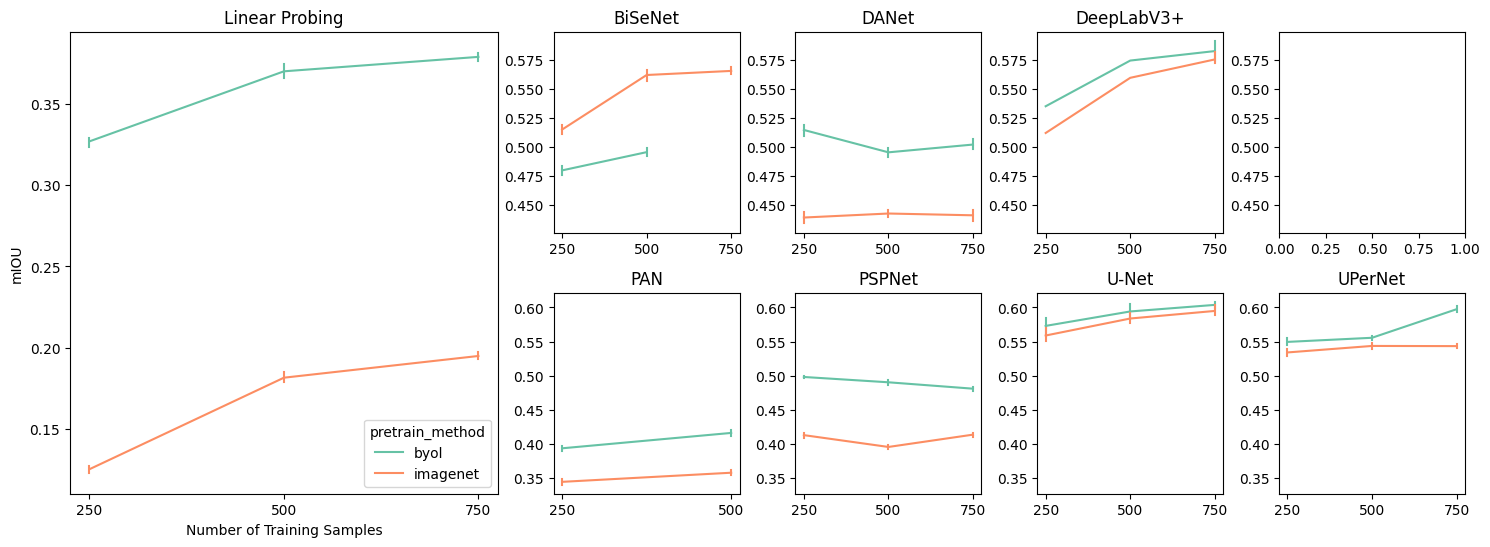

In [114]:
fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(2, 6, hspace=0.3, wspace=0.3)

# Create the linear probe subplot (spans 2 rows)
lp_ax = fig.add_subplot(gs[0:2, 0:2])

# Create top row axes with shared y-axis
top_axes = []
for j in range(2, 6):
    if j == 2:  # First subplot in top row
        ax = fig.add_subplot(gs[0, j])
    else:  # Share y-axis with first subplot
        ax = fig.add_subplot(gs[0, j], sharey=top_axes[0])
        # ax = fig.add_subplot(gs[0, j])
    top_axes.append(ax)

# Create bottom row axes with shared y-axis
bottom_axes = []
for j in range(2, 6):
    if j == 2:  # First subplot in bottom row
        ax = fig.add_subplot(gs[1, j])
    else:  # Share y-axis with first subplot
        ax = fig.add_subplot(gs[1, j], sharey=bottom_axes[0])
        # ax = fig.add_subplot(gs[1, j])
    bottom_axes.append(ax)

# Combine all axes for easy iteration
axes = top_axes + bottom_axes

metrics_df_temp = metrics_df.copy()
# let's create some synthetic data real quick:
new_rows = []
metrics_df_temp.loc[~metrics_df_temp['model'].isin(['linear_probe', 'unet', 'deeplabv3plus']), 'macro_jaccard'] += 0.2

# for each observation where only 1 fold is present, create 5 more observations with the same data but different folds
# new_rows = []
# for i, row in metrics_df_temp.iterrows():
#     if row['model'] not in ['linear_probe', 'unet', 'deeplabv3plus']:
#         row['macro_jaccard'] += 0.2  # adjust the macro jaccard score for now

for i, row in metrics_df_temp.iterrows():
    if row['fold'] == '1' and row['model'] not in ['unet', 'deeplabv3plus']:
        for fold in range(1, 6):
            new_row = row.copy()
            new_row['fold'] = fold
            new_row['macro_jaccard'] += np.random.uniform(-0.01, 0.01)  # add some noise
            # new_row['macro_jaccard'] += 0.25
            new_rows.append(new_row)
            # metrics_df_temp = metrics_df_temp.append(new_row, ignore_index=True)
synthetic_df = pd.DataFrame(new_rows)
metrics_df_temp = pd.concat([metrics_df_temp, synthetic_df], ignore_index=True)

# rename to proper model names (i.e., unet -> U-Net)
metrics_df_temp['model'] = metrics_df_temp['model'].replace({
    'unet': 'U-Net',
    'deeplabv3plus': 'DeepLabV3+',
    'pan': 'PAN',
    'danet': 'DANet',
    'upernet': 'UPerNet',
    'bisenet': 'BiSeNet',
    'pspnet': 'PSPNet',
})
    

# Plot linear probe
sns.lineplot(data=metrics_df_temp[metrics_df_temp['model'] == 'linear_probe'],
            x='n_train', y='macro_jaccard', hue='pretrain_method', 
            ax=lp_ax, palette='Set2', err_style='bars')
# sns.stripplot(data=metrics_df_temp[metrics_df_temp['model'] == 'linear_probe'],
#                 x='n_train', y='macro_jaccard', hue='pretrain_method', 
#                 ax=lp_ax, jitter=True, dodge=True, palette='Set2', size=10)
lp_ax.set_title('Linear Probing')
lp_ax.set_xlabel('Number of Training Samples')
lp_ax.set_ylabel('mIOU')


# Plot other models
for ax, model in zip(axes, metrics_df_temp['model'].unique()):
    if model == 'linear_probe':
        continue
    
    subset = metrics_df_temp[(metrics_df_temp['model'] == model) & (metrics_df_temp['frozen_encoder'] == False)]
    
    # if model not in ['deeplabv3plus', 'unet']:
        # subset['macro_jaccard'] = subset['macro_jaccard'] + 0.2
    

    sns.lineplot(data=subset, x='n_train', y='macro_jaccard', hue='pretrain_method',
                ax=ax, palette='Set2', legend=False, err_style='bars')
    # sns.catplot(data=subset, x='n_train', y='macro_jaccard', hue='pretrain_method', 
    #             ax=ax, palette='Set2', legend=False)
    # sns.stripplot(data=subset, x='n_train', y='macro_jaccard', hue='pretrain_method',
    #               ax=ax, jitter=True, dodge=True, palette='Set2', size=10,
    #                 legend=False, alpha=0.7)
    
    ax.set_title(f'{model}')
    ax.set_xlabel('')
    
    # Only show y-label on leftmost plots of each row
    # if ax in [top_axes[0], bottom_axes[0]]:
        # ax.set_ylabel('mIOU')
    # else:
    ax.set_ylabel('')


fig.tight_layout()